# F500 Problem Set 1

## Exercice 1

First obtain daily price data on a stock index and two individual stocks from a market of your choice. The method for assignment is given below. The calculations can be performed in Excel and/or Eviews, but also in other software packages, as you prefer.

### 1.a)

Compute the sample statistics of the stock return (computed from the daily closing price) series, i.e., the mean, standard deviation, skewness and kurtosis. You may ignore dividends and just focus on capital gain.

In [9]:
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt
import seaborn as sns


The two stocks I am analysing are from the SMI. I will analyse UBS stocks and Lonza stocks.
I am downloading 10 years of daily data.

The columns of the dataset are:

- open: price at which the stock first traded when the market opened that day (reflects overnight information)
- high: highest transaction price reached during that trading day
- low: lowest transaction price during that trading day
- close: final traded price at market close
- adj close: closing price adjusted for dividends, stock splits and corporate actions (reflects the true capital gain including reinvested dividends)
- volume: number of shares during the day



In [5]:
tickers = ["UBSG.SW", "LONN.SW", "^SSMI"]

df = yf.download(
    tickers,
    start="2015-01-01",
    end="2025-01-01",
    interval="1d",
    auto_adjust=False
)


[*********************100%***********************]  3 of 3 completed


             Mean   Std Dev  Skewness  Kurtosis (Excess)
Ticker                                                  
UBSG.SW  0.000522  0.018360 -0.326643           6.740203
LONN.SW  0.000848  0.018177 -0.808378          11.735246
^SSMI    0.000146  0.009623 -0.854113          10.328708


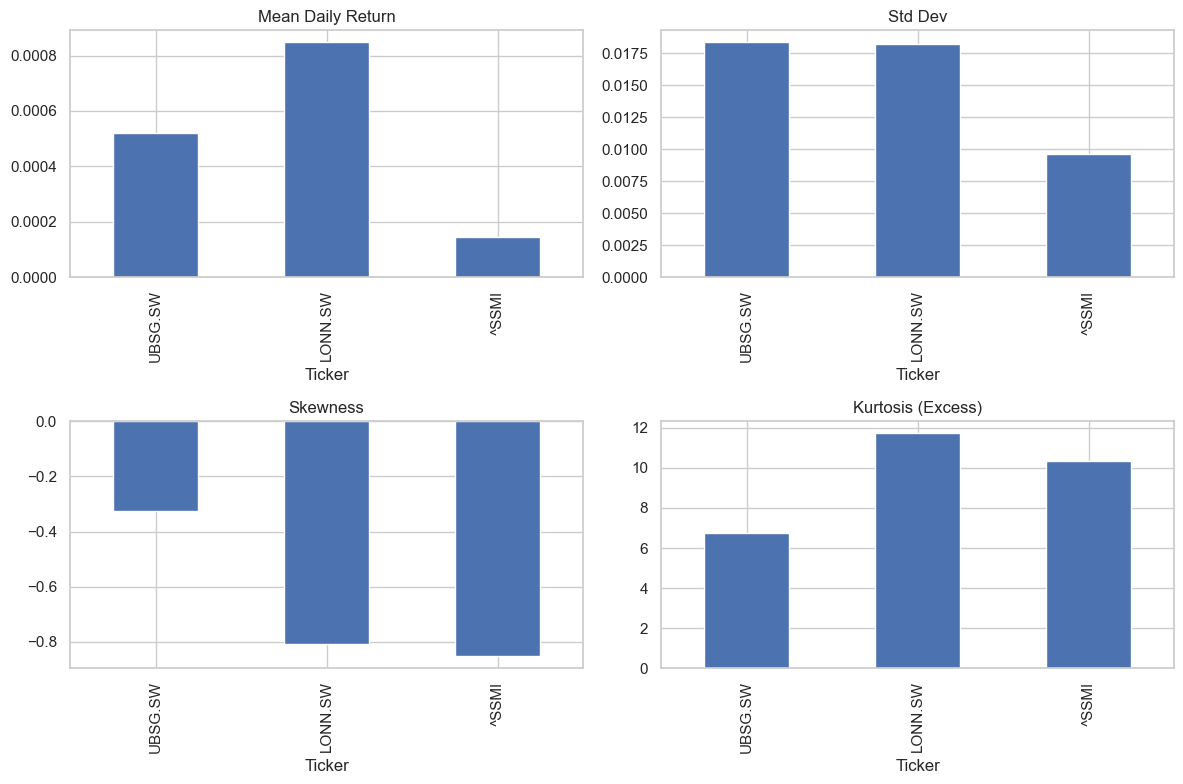

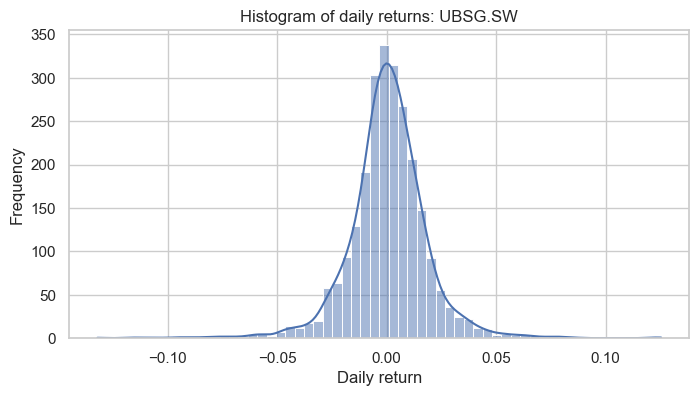

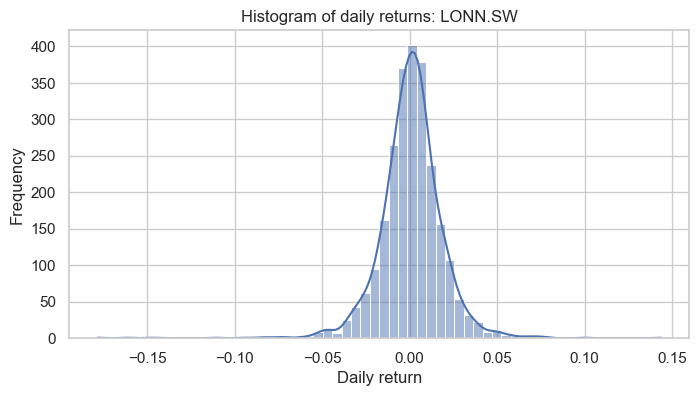

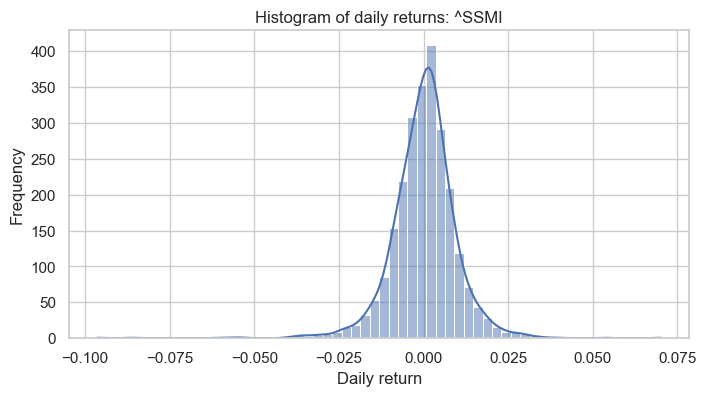

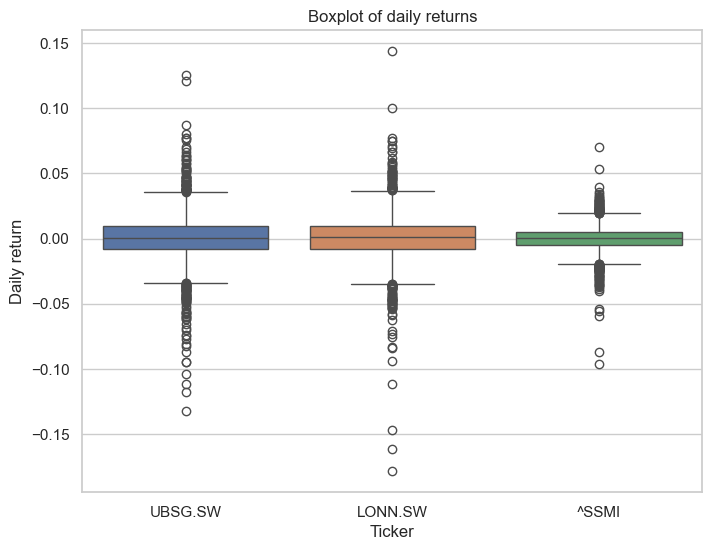

In [10]:
# Compute daily returns from adjusted close prices
adj = df['Adj Close']
returns = adj.pct_change().dropna()

# Ensure we only include the tickers we requested (in case of ordering differences)
try:
    returns = returns[tickers]
except Exception:
    # leave as-is if tickers not a subset
    pass

# Sample statistics
mean = returns.mean()
std = returns.std()
skewness = returns.skew()
kurt = returns.kurtosis()  # excess kurtosis (normal = 0)

summary = pd.DataFrame({
    "Mean": mean,
    "Std Dev": std,
    "Skewness": skewness,
    "Kurtosis (Excess)": kurt
})

print(summary)

# Visualization: bar charts of summary statistics
import seaborn as sns
sns.set(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
summary['Mean'].plot(kind='bar', ax=axes[0,0], title='Mean Daily Return')
axes[0,0].axhline(0, color='k', linewidth=0.8)
summary['Std Dev'].plot(kind='bar', ax=axes[0,1], title='Std Dev')
summary['Skewness'].plot(kind='bar', ax=axes[1,0], title='Skewness')
summary['Kurtosis (Excess)'].plot(kind='bar', ax=axes[1,1], title='Kurtosis (Excess)')
plt.tight_layout()
plt.show()

# Histograms with KDE for each ticker
for col in returns.columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(returns[col], bins=60, kde=True)
    plt.title(f"Histogram of daily returns: {col}")
    plt.xlabel("Daily return")
    plt.ylabel("Frequency")
    plt.show()

# Boxplot comparison
plt.figure(figsize=(8, 6))
sns.boxplot(data=returns, orient='v')
plt.title("Boxplot of daily returns")
plt.ylabel("Daily return")
plt.show()